In [1]:
# Reload other .py files without having to restart the kernel
%load_ext autoreload
%autoreload 2

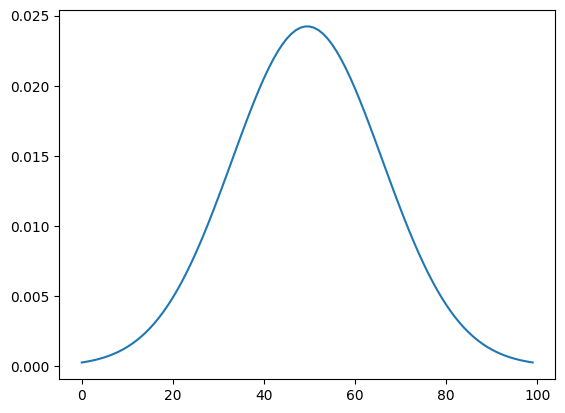

In [1]:
from torch.distributions import normal
import torch
import matplotlib.pyplot as plt

N = 100
myNorm = normal.Normal(0, 1)
targets = torch.linspace(-3, 3, N)

samples = myNorm.log_prob(targets).exp()
samples /= samples.sum()

plt.plot(samples)
plt.show()

c:\Users\Nicholas\anaconda3\envs\ComputerVision\Lib\site-packages\torch\functional.py:539: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\TensorShape.cpp:3638.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


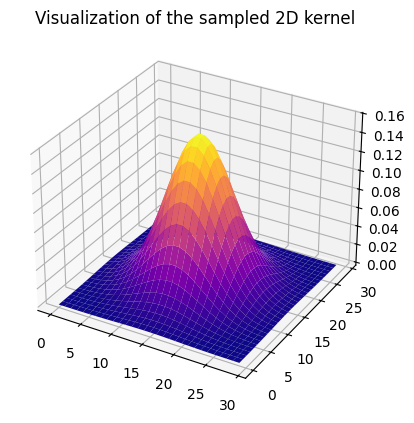

In [2]:
kernel_size = 30
distribution = normal.Normal(loc=0, scale=1)
gaussianFilter2d = distribution.log_prob(torch.linspace(-3, 3, kernel_size)).exp()
gaussianFilter2d = gaussianFilter2d[:, None] * gaussianFilter2d[None, :]

coords = torch.meshgrid(
    torch.arange(kernel_size),
    torch.arange(kernel_size)
)

fig, ax = plt.subplots(subplot_kw={'projection': '3d'})
ax.plot_surface(coords[0], coords[1], gaussianFilter2d, cmap='plasma')
plt.title('Visualization of the sampled 2D kernel')
plt.show()

# Layer Shape Testing

In [3]:

TOTAL_CHANNELS = 32
NUM_GROUPS = 8
CHANNELS_PER_GROUP = TOTAL_CHANNELS // NUM_GROUPS
tens = torch.repeat_interleave(torch.arange(0, NUM_GROUPS), repeats=CHANNELS_PER_GROUP, dim=0)
print(tens.tolist())

tens = torch.reshape(tens, (-1, NUM_GROUPS))
tens = tens.transpose(1, 0)
tens = tens.reshape(-1)

print(tens.tolist())

[0, 0, 0, 0, 1, 1, 1, 1, 2, 2, 2, 2, 3, 3, 3, 3, 4, 4, 4, 4, 5, 5, 5, 5, 6, 6, 6, 6, 7, 7, 7, 7]
[0, 2, 4, 6, 0, 2, 4, 6, 0, 2, 4, 6, 0, 2, 4, 6, 1, 3, 5, 7, 1, 3, 5, 7, 1, 3, 5, 7, 1, 3, 5, 7]


In [4]:
from K2.Blocks import ShuffleBlock

B, C, H, W = 2, 8, 3, 3
sample = torch.zeros((B, C, H, W), dtype=torch.int64)
sample[:, torch.arange(C), :, :] = torch.arange(C).reshape(1, C, 1, 1)
# print(sample)

layer = ShuffleBlock(groups=1)
# print(layer(sample))
output = layer(sample)
print(output.shape)

torch.Size([2, 8, 3, 3])


In [5]:
import torch
from Models import shuffleNetMini

H = torch.arange(16, 64, 3)
K = torch.arange(1, 5)

device = 'cuda' if torch.cuda.is_available() else 'cpu'

shuffleNetMini = shuffleNetMini.to(device)
randomTensor = torch.randn((16, 3, 80, 80)).to(device)

output = shuffleNetMini(randomTensor)
print(randomTensor.shape)
print(output.shape)


torch.Size([16, 3, 80, 80])
torch.Size([16, 2])


In [6]:
from K2.Blocks import ShuffledLinearBottleneck

B, C, H, W = 64, 3, 5, 5

for h in range(5, 81):

    randomTensor = torch.randn((B, C, h, h))
    layer = ShuffledLinearBottleneck(
        in_channels=3,
        out_channels=8,
        stride=2,
        groups=1
    )

    output = layer(randomTensor)
print(randomTensor.shape)
print(output.shape)

torch.Size([64, 3, 80, 80])
torch.Size([64, 8, 40, 40])


# Profiling Testing

{'layerName': '_ShuffledLinearBottleneck 0', 'param_count': 210, 'train_stats': {'cpu_time_μs': 1596.7699999999998, 'device_time_μs': 1264.7, 'device_memory_usage_mb': 95.29300000000003, 'megaflops': 15.149999999999986}, 'inference_stats': {'cpu_time_μs': 1353.6660000000002, 'device_time_μs': 1115.96, 'device_memory_usage_mb': 3.2039999999999993, 'megaflops': 15.149999999999986}}
{'layerName': '_ShuffledLinearBottleneck 1', 'param_count': 2116, 'train_stats': {'cpu_time_μs': 1524.6319999999996, 'device_time_μs': 1810.7, 'device_memory_usage_mb': 55.69000000000003, 'megaflops': 70.25}, 'inference_stats': {'cpu_time_μs': 1239.1840000000002, 'device_time_μs': 1309.54, 'device_memory_usage_mb': -2.887, 'megaflops': 70.25}}
{'layerName': '_BatchNorm2d 2', 'param_count': 32, 'train_stats': {'cpu_time_μs': 179.38400000000001, 'device_time_μs': 84.8, 'device_memory_usage_mb': 0.3170000000000001, 'megaflops': 0.0}, 'inference_stats': {'cpu_time_μs': 127.056, 'device_time_μs': 51.0, 'device_memo

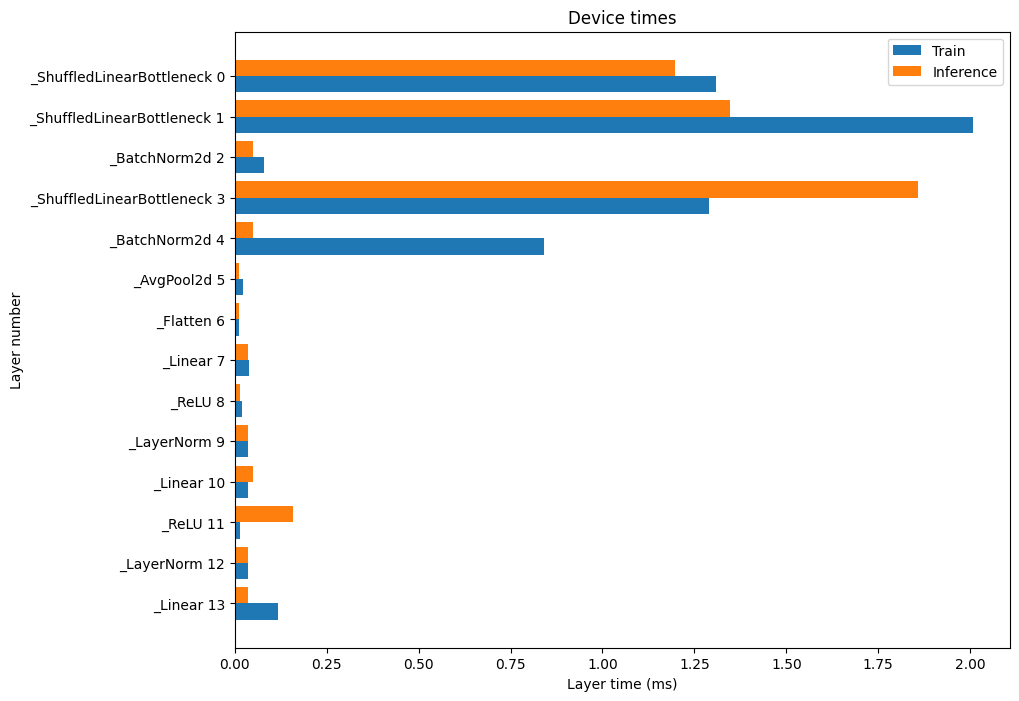

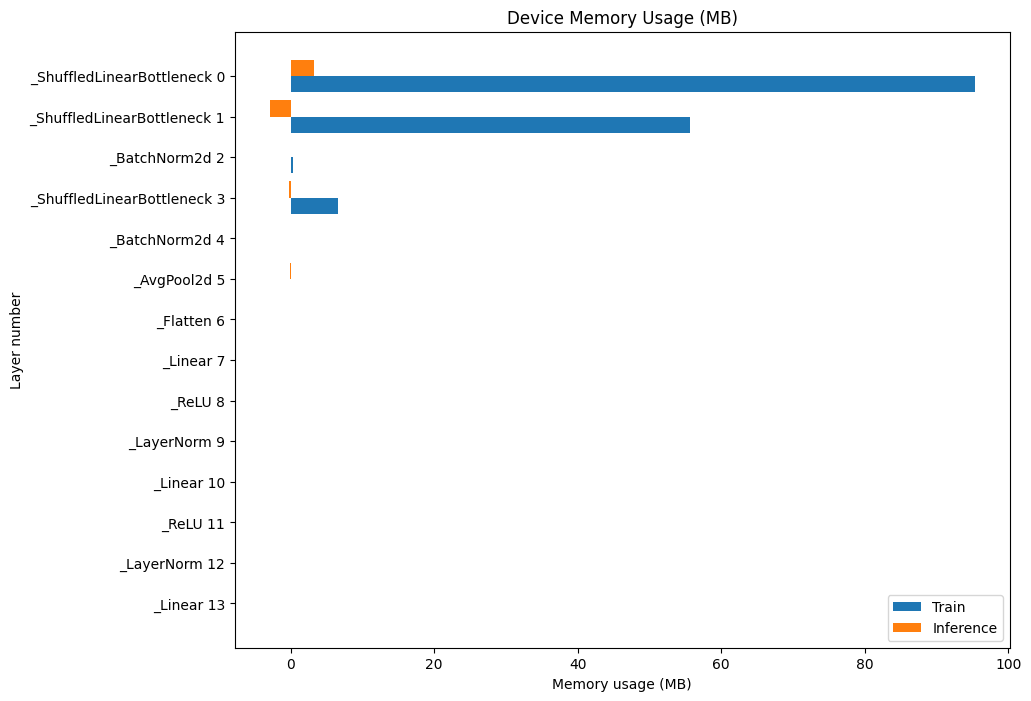

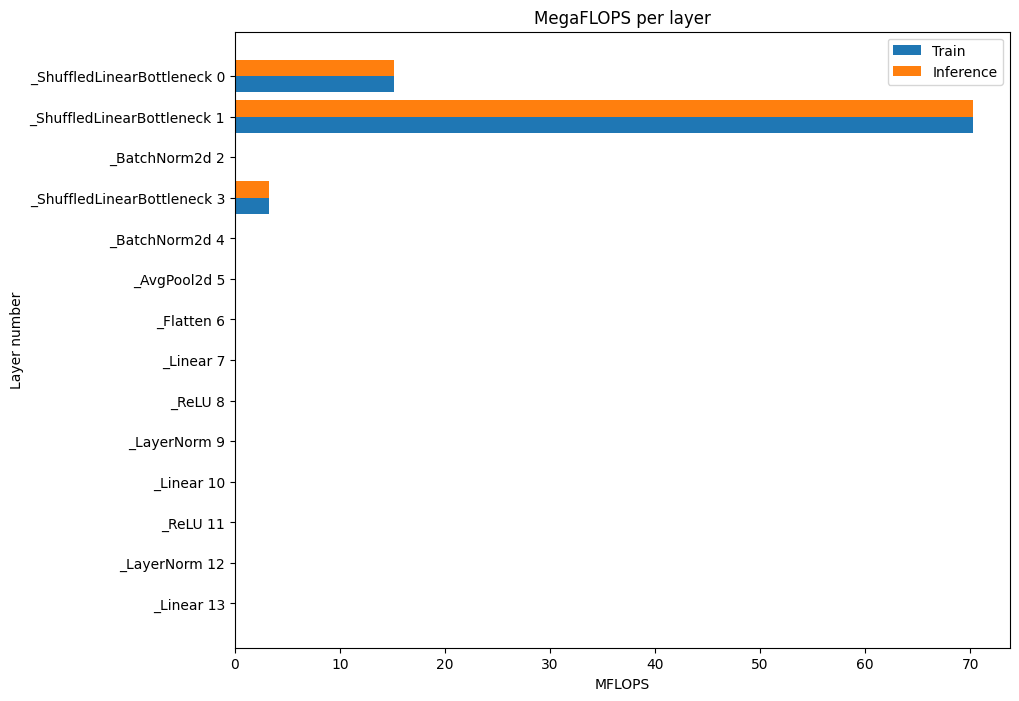

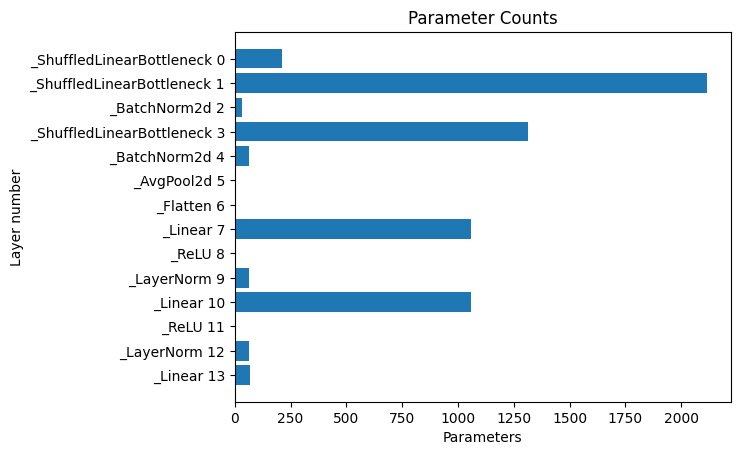

In [10]:
from Models import shuffleNetMini
from K2.ModelProfiling import profileModelLayers, plotModelProfileGraphs

model = shuffleNetMini
INPUT_SIZE = (64, 3, 80, 80)

res = profileModelLayers(model, INPUT_SIZE)
for k in res:
    print(k)

plotModelProfileGraphs(model, INPUT_SIZE)

In [24]:
from Models import *
from K2.ModelProfiling import compareModelStatistics

models = {
    'separableNet': separableNet,
    'shiftNet': shiftNet,
    'shuffleNet': shuffleNet,
    'shuffleNetMini': shuffleNetMini
}


input_size = (64, 3, 80, 80)
stats = compareModelStatistics(models, input_size)
stats.head()

,Model Name,cpu_time_μs_train,device_time_μs_train,device_memory_usage_mb_train,megaflops_train,cpu_time_μs_inference,device_time_μs_inference,device_memory_usage_mb_inference,megaflops_inference,param_count
0,separableNet,6452.458,5876.74,79.064,246.52,5831.796,5332.94,1.144050e-15,246.52,79186
1,shiftNet,7081.986,6502.54,171.154,523.90,6512.238,6080.32,1.000000e-03,523.90,79186
2,shuffleNet,8428.996,7836.50,223.191,150.81,7120.228,6568.96,1.000000e-03,150.81,31576
3,shuffleNetMini,5522.970,4993.54,158.020,88.93,4820.368,4267.60,2.000000e-03,88.93,6040
